# Notebook 9 — Linear Algebra Fundamentals

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 9 — Linear Algebra Fundamentals**. The lecture introduced the core language of linear algebra — vectors, matrices, products, norms, inverses — and gave both an *arithmetic* interpretation (solving systems of equations) and a *geometric* interpretation (transforming space). Here we will make all of those ideas concrete in Python and visualize what they actually look like.

### By the end of this notebook you will be able to:
- Create and inspect **NumPy vectors and matrices** and check their shapes.
- Perform **matrix multiplication**, **transpose**, and check **commutativity** (or its absence).
- Compute the **identity matrix**, **zero matrix**, **matrix inverse**, and **pseudo-inverse**.
- Compute **inner products**, **outer products**, and **vector norms**.
- **Visualize 2-D vectors** and see how matrices **transform** them geometrically.
- Connect each algebraic operation to a concrete neuroscience or data-analysis context.

### Table of contents
1. [Setup](#section-1)
2. [Vectors and matrices in NumPy](#section-2)
3. [Matrix multiplication](#section-3)
4. [Special matrices: zero, identity, inverse, pseudo-inverse](#section-4)
5. [Inner product, outer product, and norm](#section-5)
6. [Geometric perspective: visualizing linear transformations](#section-6)
7. [Application: decoding a simulated neural population](#section-7)
8. [Lego-style exercises](#section-8)

> **How to read this notebook.** Markdown cells explain *why* we do something and the concept behind it. Code cells implement it. Look out for **`▶ Task`** boxes — those are the exercises. Difficulty tags:
> - 👨🏻‍🏫 ⭐️ — Run, understand, and slightly modify provided code.
> - 🧐 ⭐️⭐️ — Repair a small bug, complete missing lines, or write a short function.
> - 😎 ⭐️⭐️⭐️ — Build a fuller workflow or extend the analysis.
>
> If you are stuck, ask the TAs or use the course GPT bot: https://chatgpt.com/g/g-69fc9bfc9a748191a912a124800d9254-qmn-teaching-assistant-bot


<a id="section-1"></a>
## 1. Setup

Make sure the `qmn` conda environment is active and selected as the kernel (top-right corner of VS Code). Then run the cell below to import everything we need and set a consistent plotting style.


In [2]:
# --- Import the scientific Python stack
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from cycler import cycler
from ipywidgets import interact

# Consistent plot style for the course
plt.rcParams.update({
    "figure.figsize": (5, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=[
        "#1f77b4",  # blue
        "#ff7f0e",  # orange
        "#5b2c83",  # purple
        "#2ca02c",  # green
    ]),
})

print(f"NumPy version: {np.__version__}")
print("Setup complete.")


NumPy version: 2.4.3
Setup complete.


### A helper function for drawing 2-D vectors

Throughout this notebook we will plot 2-D vectors as arrows. The function below wraps `matplotlib`'s `ax.quiver` into something convenient: give it a list of vectors and it draws each one starting from the origin.


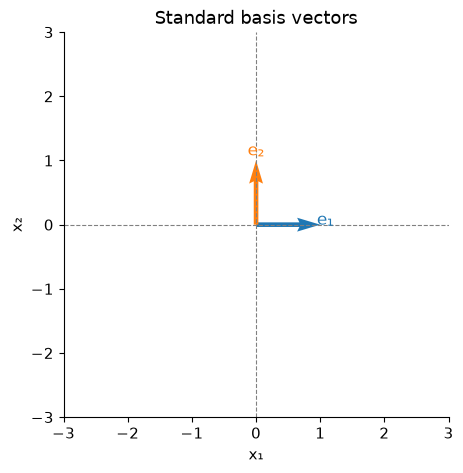

In [3]:
# --- Helper: draw 2-D column vectors as arrows from the origin
def plot_vectors(vectors, labels=None, colors=None, ax=None, lim=3.0, ax_label = False):
    """
    Plot a list of 2-D column vectors as arrows from the origin.

    Parameters
    ----------
    vectors : list of array-like, each of shape (2,) or (2,1)
    labels  : list of strings (optional)
    colors  : list of color strings (optional)
    ax      : matplotlib Axes (created if None)
    lim     : half-width of the axis range
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    default_colors = ["#1f77b4", "#ff7f0e", "#5b2c83", "#2ca02c", "#d62728"]
    if colors is None:
        colors = default_colors

    for i, v in enumerate(vectors):
        v = np.array(v).flatten()   # works for (2,) or (2,1)
        col = colors[i % len(colors)]
        ax.quiver(0, 0, v[0], v[1],
                  angles="xy", scale_units="xy", scale=1,
                  color=col, width=0.012)
        if ax_label:
            ax.hlines(v[1], 0, v[0], color=col, linestyles='--', alpha = 0.5)
            ax.vlines(v[0], 0, v[1], color=col, linestyles='--', alpha = 0.5)
            if labels is not None:
                ax.text(v[0] * 1.08 / 10, v[1] * 1.08, fr"{labels[i]}$_2$",
                                            color=col, fontsize=12, ha="center")
                ax.text(v[0] * 1.08, v[1] * 1.08 / 10, fr"{labels[i]}$_1$",
                                                            color=col, fontsize=12, ha="center")
        if labels is not None:
            ax.text(v[0] * 1.08, v[1] * 1.08, labels[i],
                    color=col, fontsize=12, ha="center")
            

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.axvline(0, color="gray", lw=0.8, ls="--")
    ax.set_aspect("equal")
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    return ax

# Quick smoke test
ax = plot_vectors([[1, 0], [0, 1]], labels=["e₁", "e₂"])
ax.set_title("Standard basis vectors")
plt.show()


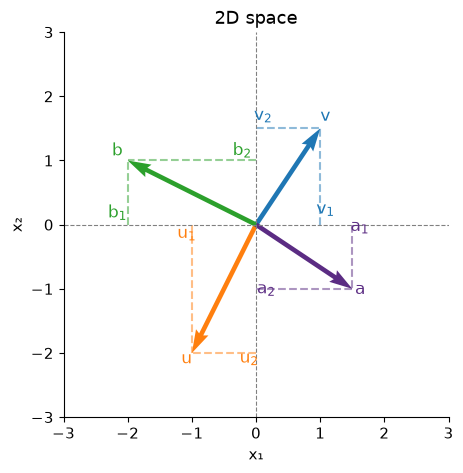

In [4]:
# Plot the following vectors using the plot_vectors function!
# v = [v1, v2] = [1, 1]
# u = [u1, u2] = [-1, -1]
# a = [a1, a2] = [1, -1]
# b = [b1, b2] = [-3, 2]
ax = plot_vectors([[1, 1.5], [-1, -2], [1.5, -1], [-2, 1]], labels=["v", "u", "a", "b"], ax_label=True)
ax.set_title("2D space")
plt.show()

<a id="section-2"></a>
## 2. Vectors and matrices in NumPy

In NumPy, a **vector** is a 1-D array and a **matrix** is a 2-D array. The most important habit when doing linear algebra in NumPy is to **always check the shape** of your arrays — dimension mismatches are the most common source of bugs.

| Shape | What it is |
|-------|------------|
| `(n,)` | 1-D array ("flat" vector) |
| `(n, 1)` | Column vector |
| `(1, n)` | Row vector |
| `(m, n)` | Matrix with `m` rows and `n` columns |

We will prefer the *explicit* `(n, 1)` and `(1, n)` shapes for vectors so that broadcasting and multiplication behave predictably.

**Inspecting the size of your matrices will be very useful for debugging your code.**

In [5]:
# --- Creating vectors
v_flat   = np.array([2, 3])           # shape (2,)  — flat
v_col    = np.array([[2], [3]])        # shape (2,1) — column vector
v_row    = np.array([[2, 3]])          # shape (1,2) — row vector

print("v_flat  shape:", v_flat.shape)   # (2,)
print("v_col   shape:", v_col.shape)    # (2,1)
print("v_row   shape:", v_row.shape)    # (1,2)


v_flat  shape: (2,)
v_col   shape: (2, 1)
v_row   shape: (1, 2)


In [6]:
# Addition of vectors
def addition_interactive(a_size = 1, a_angle = -np.pi/4):
    b = np.array([2, 2])
    a = np.array([a_size * np.cos(a_angle), a_size * np.sin(a_angle)])
    a_plus_b = a + b
    ax = plot_vectors([a, b, a_plus_b], labels=["a", "b", "a+b"], ax_label=False)
    ax.set_title(r'Addition of $\boldsymbol{a}$ and $\boldsymbol{b}$')
    plt.show()
_ = interact(addition_interactive, a_size = (-3, 3, 0.1), a_angle = (-np.pi, np.pi, np.pi/20))

interactive(children=(FloatSlider(value=1.0, description='a_size', max=3.0, min=-3.0), FloatSlider(value=-0.78…

In [7]:
# --- Creating a matrix
A = np.array([[1, 2, 3],
              [4, 5, 6]])   # shape (2, 3) — 2 rows, 3 columns

print("A =\n", A)
print("shape  :", A.shape)   # (2, 3)
print("ndim   :", A.ndim)    # 2 (two dimensions)
print("size   :", A.size)    # 6 (total number of elements)
print("dtype  :", A.dtype)   # int64



A =
 [[1 2 3]
 [4 5 6]]
shape  : (2, 3)
ndim   : 2
size   : 6
dtype  : int64


In [8]:
# --- Accessing elements and slices
print("A[0, :]  — first row  :", A[0, :])   # [1 2 3]
print("A[:, 1]  — second col :", A[:, 1])   # [2 5]
print("A[1, 2]  — element    :", A[1, 2])   # 6


A[0, :]  — first row  : [1 2 3]
A[:, 1]  — second col : [2 5]
A[1, 2]  — element    : 6


### Transpose

The **transpose** of a matrix swaps its rows and columns: $A^\top_{ij} = A_{ji}$.

Neuroscience relevance: if `A` has shape `(neurons, time)`, then `A.T` has shape `(time, neurons)` — which is often what you need to compute a covariance matrix or multiply with another array.

![gif](assets/09/Matrix_transpose.gif)

(source: https://evisp.github.io/ml-handbook/02-math/linear-algebra)

In [9]:
# --- Transpose
print("A shape  :", A.shape)      # (2, 3)
print("A.T shape:", A.T.shape)    # (3, 2)
print("A.T =\n", A.T)


A shape  : (2, 3)
A.T shape: (3, 2)
A.T =
 [[1 4]
 [2 5]
 [3 6]]


> **▶ Task 2.1 — 👨🏻‍🏫 ⭐️ Shape detective.**
>
> Run the cell below and examine the shapes of the arrays. For each pair, predict whether `np.dot(X, Y)` will work *before* you run it. Then run and verify.
>
> | | `X` | `Y` | Will `np.dot(X, Y)` work? |
> |---|-----|------|---------------------------|
> | a | `(3,2)` | `(2,4)` | ? |
> | b | `(3,2)` | `(3,4)` | ? |
> | c | `(1,5)` | `(5,1)` | ? |
> | d | `(5,)` | `(5,)` | ? |


In [10]:
# TODO 2.1 — for each pair below, check the shapes and try np.dot(X, Y)
rng = np.random.default_rng(42)

Xa = rng.standard_normal((3, 2))
Ya = rng.standard_normal((2, 4))

Xb = rng.standard_normal((3, 2))
Yb = rng.standard_normal((3, 4))

Xc = rng.standard_normal((1, 5))
Yc = rng.standard_normal((5, 1))

Xd = rng.standard_normal((5,))
Yd = rng.standard_normal((5,))

# Your predictions go here as comments, then uncomment each np.dot to test:
print("a:", np.dot(Xa, Ya).shape)   # should work — (3,4)  # TO BE UNCOMMENTED
# print("b:", np.dot(Xb, Yb).shape)  # should FAIL — shapes incompatible
print("c:", np.dot(Xc, Yc).shape)   # should work — (1,1)  # TO BE UNCOMMENTED
print("d:", np.dot(Xd, Yd))          # should work — scalar inner product  # TO BE UNCOMMENTED


a: (3, 4)
c: (1, 1)
d: 0.6300478240011158


<a id="section-3"></a>
## 3. Matrix multiplication

Matrix multiplication combines two matrices according to the rule:

$$
(AB)_{ij} = \sum_{k} A_{ik}\, B_{kj}
$$

For this to be defined, the **inner dimensions must match**: if $A$ is $(m \times k)$ and $B$ is $(k \times n)$, the result is $(m \times n)$.

![gif](assets/09/matrix-multiplication-2040537183.gif)

(source: https://evisp.github.io/ml-handbook/02-math/linear-algebra)

In NumPy you can write matrix multiplication in three equivalent ways:

```python
A @ B          # preferred (Python 3.5+)
np.matmul(A, B)
np.dot(A, B)   # works for 2-D arrays; avoid for higher-dimensional tensors
```

Do **not** use `A * B` for matrix multiplication — that is element-wise multiplication (Hadamard product), which is a completely different operation.


In [11]:
# --- Basic matrix multiplication
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

AB = A @ B
print("A =\n", A)
print("B =\n", B)
print("A @ B =\n", AB)
print("np.dot(A,B) = \n", np.dot(A, B))
# Verify one element by hand: (A@B)[0,0] = 1*5 + 2*7 = 19
print("\nManual check (A@B)[0,0] =", 1*5 + 2*7)


A =
 [[1 2]
 [3 4]]
B =
 [[5 6]
 [7 8]]
A @ B =
 [[19 22]
 [43 50]]
np.dot(A,B) = 
 [[19 22]
 [43 50]]

Manual check (A@B)[0,0] = 19


### Non-commutativity

One of the key facts stressed in the lecture: **matrix multiplication is generally NOT commutative**. That is, $AB \neq BA$ in general. This is fundamentally different from scalar multiplication (where $ab = ba$ always).

The **commutator** of two matrices is defined as $[A, B] = AB - BA$. If $[A, B] = 0$ the matrices commute; otherwise they do not.


In [12]:
# --- Non-commutativity demonstration
BA = B @ A
print("A @ B =\n", AB)
print("B @ A =\n", BA)
print("Commutator [A,B] = A@B - B@A =\n", AB - BA)
print("\nAre they equal?", np.allclose(AB, BA))


A @ B =
 [[19 22]
 [43 50]]
B @ A =
 [[23 34]
 [31 46]]
Commutator [A,B] = A@B - B@A =
 [[ -4 -12]
 [ 12   4]]

Are they equal? False


**Neuroscience context.** Non-commutativity matters in practice whenever operations are applied in sequence: applying a rotation *then* a scaling gives a different result than scaling *then* rotating. In neural network models, the order in which weight matrices are multiplied determines the computation performed.


> **▶ Task 3.1 — 🧐 ⭐️⭐️ Fix the commutator function.**
>
> The function below is supposed to compute the commutator $[A,B] = AB - BA$ and return `True` if the matrices commute, `False` otherwise. It has **one bug**. Find it, fix it, and verify on `A`, `B` above and on two diagonal matrices (which should commute).


In [13]:
# TODO 3.1 — find and fix the bug, then test
def commutator(A, B, tol=1e-10):
    """Return (C, do_commute) where C = AB - BA."""
    C = A @ B - B @ A   # BUG: was written as A @ B + B @ A  # FIXED
    do_commute = np.allclose(C, np.zeros_like(C), atol=tol)
    return C, do_commute

# Test 1: A and B from above — should NOT commute
C, comm = commutator(A, B)
print("[A,B] =\n", C)
print("A and B commute:", comm)   # expected: False

# Test 2: two diagonal matrices — SHOULD commute
D1 = np.diag([2.0, 3.0])
D2 = np.diag([5.0, 7.0])
_, comm2 = commutator(D1, D2)
print("D1 and D2 commute:", comm2)   # expected: True


[A,B] =
 [[ -4 -12]
 [ 12   4]]
A and B commute: False
D1 and D2 commute: True


<a id="section-4"></a>
## 4. Special matrices: zero, identity, inverse, pseudo-inverse

### Zero matrix and identity matrix

The **zero matrix** $\mathbf{0}$ has every entry equal to 0. Adding it to any matrix leaves it unchanged: $A + \mathbf{0} = A$.

The **identity matrix** $I_n$ is the square $n \times n$ matrix with ones on the diagonal and zeros everywhere else. Multiplying any compatible matrix by $I$ leaves it unchanged: $AI = IA = A$.


In [14]:
# --- Zero matrix and identity matrix
Z = np.zeros((3, 3))
I = np.eye(3)

print("Zero matrix Z =\n", Z)
print("Identity matrix I =\n", I)

# Verify: A @ I == A for an arbitrary A
A_test = rng = np.random.default_rng(0); A_test = rng.integers(1, 10, size=(3, 3)).astype(float)
print("\nA_test =\n", A_test)
print("A_test @ I =\n", A_test @ I)
print("A_test @ I == A_test:", np.allclose(A_test @ I, A_test))


Zero matrix Z =
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Identity matrix I =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

A_test =
 [[8. 6. 5.]
 [3. 3. 1.]
 [1. 1. 2.]]
A_test @ I =
 [[8. 6. 5.]
 [3. 3. 1.]
 [1. 1. 2.]]
A_test @ I == A_test: True


### Inverse

The **inverse** $A^{-1}$ of a square matrix $A$ satisfies $A A^{-1} = A^{-1} A = I$. It exists only when $A$ is *square* and *non-singular* (i.e. full rank, determinant ≠ 0).

**Neuroscience use case:** inverting the forward model $\mathbf{y} = A\mathbf{x}$ to recover the latent state $\mathbf{x} = A^{-1}\mathbf{y}$ — for example, going from electrode recordings back to source activations.


In [15]:
# --- Matrix inverse
M = np.array([[2.0, 1.0],
              [5.0, 3.0]])

M_inv = np.linalg.inv(M)
print("M =\n", M)
print("M_inv =\n", M_inv.round(4))

# Verify: M @ M_inv should equal I
product = M @ M_inv
print("M @ M_inv =\n", product.round(10))
print("Is identity:", np.allclose(product, np.eye(2)))


M =
 [[2. 1.]
 [5. 3.]]
M_inv =
 [[ 3. -1.]
 [-5.  2.]]
M @ M_inv =
 [[ 1.  0.]
 [-0.  1.]]
Is identity: True


### Pseudo-inverse

When $A$ is **not square** (or is singular), the ordinary inverse does not exist. The **Moore-Penrose pseudo-inverse** $A^+$ is the generalization: it gives the least-squares solution to the system $A\mathbf{x} = \mathbf{b}$ via $\mathbf{x} = A^+\mathbf{b}$.

$$
A^+ = \lim_{\delta \to 0} (A^\top A + \delta I)^{-1} A^\top
$$

NumPy computes it via SVD internally: `np.linalg.pinv(A)`.

**Why it matters in neuroscience:** most decoding problems are *over- or under-determined*. For example, trying to reconstruct a stimulus from hundreds of neurons when you only have a handful of trials. The pseudo-inverse (or regularized versions of it) is the workhorse of linear decoding.


In [16]:
# --- Pseudo-inverse of a non-square matrix
# A is (3, 2): more equations than unknowns — over-determined system
A_rect = np.array([[1.0, 0.0],
                   [1.0, 1.0],
                   [0.0, 1.0]])

A_pinv = np.linalg.pinv(A_rect)
print("A_rect shape :", A_rect.shape)    # (3, 2)
print("A_pinv shape :", A_pinv.shape)    # (2, 3)
print("A_pinv =\n", A_pinv.round(4))

# A_pinv @ A_rect should be ~I (2x2)
print("\nA_pinv @ A_rect =\n", (A_pinv @ A_rect).round(4))   # should be I_2


A_rect shape : (3, 2)
A_pinv shape : (2, 3)
A_pinv =
 [[ 0.6667  0.3333 -0.3333]
 [-0.3333  0.3333  0.6667]]

A_pinv @ A_rect =
 [[1. 0.]
 [0. 1.]]


> **▶ Task 4.1 — 🧐 ⭐️⭐️ Solve a system of linear equations.**
>
> You are given a simple linear model:
>
> $$\mathbf{y} = A \mathbf{x}$$
>
> where $A$ is a known $3 \times 2$ matrix and $\mathbf{y}$ is an observed 3-D vector. Your goal is to find the *best fit* $\hat{\mathbf{x}}$ (2-D) using the pseudo-inverse.
>
> 1. Compute `x_hat = A_pinv @ y_obs`.
> 2. Compute the *residual vector* $\mathbf{r} = \mathbf{y}_{\text{obs}} - A\hat{\mathbf{x}}$.
> 3. Print the norm of the residual `np.linalg.norm(r)`. A smaller norm means a better fit.


In [17]:
# TODO 4.1 — solve the over-determined system using the pseudo-inverse
y_obs = np.array([1.2, 2.1, 0.9])   # observed 3-D vector

# 1. Compute x_hat using the pseudo-inverse computed above
x_hat = A_pinv @ y_obs   # TO BE REMOVED
print("x_hat =", x_hat.round(4))

# 2. Compute the residual
residual = y_obs - A_rect @ x_hat   # TO BE REMOVED
print("residual =", residual.round(4))

# 3. Compute the norm of the residual
print("||residual|| =", np.linalg.norm(residual).round(6))   # TO BE REMOVED


x_hat = [1.2 0.9]
residual = [ 0.  0. -0.]
||residual|| = 0.0


<a id="section-5"></a>
## 5. Inner product, outer product, and norm

### Inner product (dot product)

For two vectors $\mathbf{u}, \mathbf{v} \in \mathbb{R}^n$:

$$
\mathbf{u} \cdot \mathbf{v} = \mathbf{u}^\top \mathbf{v} = \sum_{i=1}^n u_i v_i \;\in\; \mathbb{R}
$$

The inner product is a **scalar** that measures how *aligned* the two vectors are. In neuroscience it appears everywhere: as a similarity measure between neural population vectors, as the operation a linear readout performs on population activity, and as the projection of one vector onto another.

**Geometric interpretation:** $\mathbf{u} \cdot \mathbf{v} = \|\mathbf{u}\| \|\mathbf{v}\| \cos\theta$ where $\theta$ is the angle between the vectors.


In [18]:
# --- Inner product
u = np.array([1.0, 2.0, 3.0])
v = np.array([4.0, 5.0, 6.0])

inner = np.dot(u, v)       # or: u @ v  or  np.inner(u, v)
print("u =", u)
print("v =", v)
print("u · v =", inner)    # 1*4 + 2*5 + 3*6 = 32

# Geometric version: compute the angle between u and v
cos_theta = inner / (np.linalg.norm(u) * np.linalg.norm(v))
theta_deg = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))
print(f"angle between u and v: {theta_deg:.2f}°")


u = [1. 2. 3.]
v = [4. 5. 6.]
u · v = 32.0
angle between u and v: 12.93°



In the following demo, we have two retinal neurons with varying firing rates ($r_1$ and $r_2$). We will allow our firing rates to be negative in this example. We can represent our retinal firing rates with the vector $\mathbf{r} = \begin{bmatrix} r_1\\ r_2\\ \end{bmatrix}$.

We have weights from each of these to an LGN neuron: the weight of the connection from the first retinal neuron is 1 and the weight from the second is 2. See the circuit below. We can represent our weights with the vector $\mathbf{w} = \begin{bmatrix} 1\\ 2\\ \end{bmatrix}$.

The LGN firing rate is the dot product of the retinal firing rate vector and the weight vector:

\begin{equation}
g = \mathbf{w}\cdot\mathbf{r} = w_1r_1 + w_2r_2
\end{equation}

In the following demo you will try various combinations of firing rates of the retinal neurons (thus moving the vector that corresponds to the firing rates).  When you move the retinal firing rates around, you will see the heatmap in that area appear, which shows the corresponding LGN neuron firing rate (for that combo of retina firing). Remember that this value is computed as the dot product between the retinal firing rate vector and the weight vector.

Play with the following demo and then discuss these questions:


1.   For a given length of the retinal firing rate vector, what direction maximally excites the LGN neuron (highest postsynaptic firing rate)? How does it relate to the weights vector?
2.   For a given length of the retinal firing rate vector, what direction minimally excites the LGN neuron?
3.   When does the LGN neuron have 0 firing rate? What is the relationship between the weights and retinal firing rate vector?
4.   For a given direction, how does the LGN firing rate vary with length of the retinal firing rate vector?
5.   Let's say the retinal neurons are tightly linked and the length of the retinal firing rate vector has to be 1. In other words, it has to be a unit vector. How would you find the retinal firing rates that maximally excite the LGN neuron?
6.   
**(Source example: [Neuromatch](https://compneuro.neuromatch.io/tutorials/W0D3_LinearAlgebra/student/W0D3_Tutorial2.html))**

In [19]:
def dot_product_interactive(a_size = 1, a_angle = -2*np.pi/4):
    b = np.array([2, 2])
    a = np.array([a_size * np.cos(a_angle), a_size * np.sin(a_angle)])
    a_dot_b = np.dot(a, b)
    x = np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
    theta = np.arccos(np.clip(x, -1.0, 1.0))
    proj_a_on_b = (np.dot(a,b) / np.dot(b,b)) * b
    ax = plot_vectors([a, b, proj_a_on_b], labels=["a", "b", "a.b"])
    ax.set_title(r'Projection of $\boldsymbol{a}$ on $\boldsymbol{b}$')
    plt.show()
_ = interact(dot_product_interactive, a_size = (-3, 3, 0.1), a_angle = (-np.pi, np.pi, np.pi/20))

interactive(children=(FloatSlider(value=1.0, description='a_size', max=3.0, min=-3.0), FloatSlider(value=-1.57…

In [20]:
# Imagine an LGN neuron that recieve input from two retinal cells.

def lgn_firing_rate(r1 = 1, r2 = 2, w1 = 1.5, w2 = 2.1):
    r = np.array([r1, r2])
    w = np.array([w1, w2])
    g = w.dot(r)
    ax = plot_vectors([r, w], labels=["r", "w"], ax_label=True)
    ax.set_title(rf'LGN firing rate, $g = r \cdot w$ =  {g}')
    plt.show()
_ = interact(lgn_firing_rate, r1 = (-2, 2, 0.1), r2 = (-2, 2, 0.1),
             w1 = (-2, 2, 0.1), w2 = (-2, 2, 0.1))

interactive(children=(FloatSlider(value=1.0, description='r1', max=2.0, min=-2.0), FloatSlider(value=2.0, desc…

### Norm

The **Euclidean norm** (L2 norm) of a vector is its length:

$$
\|\mathbf{v}\| = \sqrt{\mathbf{v} \cdot \mathbf{v}} = \sqrt{\sum_i v_i^2}
$$

A vector divided by its norm is a **unit vector** (norm = 1). Unit vectors are used to represent *directions* without regard to magnitude.


In [21]:
# --- Vector norm and normalisation
w = np.array([3.0, 4.0])   # 3-4-5 right triangle: expected norm = 5
norm_w = np.linalg.norm(w)
w_unit = w / norm_w

print("w =", w)
print("||w|| =", norm_w)              # 5.0
print("w / ||w|| =", w_unit.round(4)) # [0.6, 0.8]
print("||w_unit|| =", np.linalg.norm(w_unit).round(10))  # 1.0


w = [3. 4.]
||w|| = 5.0
w / ||w|| = [0.6 0.8]
||w_unit|| = 1.0


### Outer product

The **outer product** of two vectors $\mathbf{u} \in \mathbb{R}^m$ and $\mathbf{v} \in \mathbb{R}^n$ produces a **matrix**:

$$
\mathbf{u} \mathbf{v}^\top \;\in\; \mathbb{R}^{m \times n}, \quad (\mathbf{u} \mathbf{v}^\top)_{ij} = u_i v_j
$$

**Neuroscience use case:** In low-rank recurrent neural networks (low-rank RNNs), the connectivity is the outer product of two individual vectors $\mathbf{J} = \mathbf{m}\mathbf{n}^\top$, making a low-rank connectivity structure.

![image](assets/09/lorank.jpg)

A useful resource for interested students:
[low-rank RNN](https://adrian-valente.github.io/2022/06/01/low-rank-summary.html)


In [22]:
# --- Outer product
a = np.array([1.0, 2.0, 3.0])   # pre-synaptic firing rates (3 neurons)
b = np.array([4.0, 5.0])        # post-synaptic firing rates (2 neurons)

outer = np.outer(a, b)   # shape (3, 2)
print("Outer product a ⊗ b =\n", outer)
print("Shape:", outer.shape)

# Alternative: column_vector @ row_vector
outer_alt = a.reshape(-1, 1) @ b.reshape(1, -1)
print("\nSame result via @:", np.allclose(outer, outer_alt))


Outer product a ⊗ b =
 [[ 4.  5.]
 [ 8. 10.]
 [12. 15.]]
Shape: (3, 2)

Same result via @: True


> **▶ Task 5.1 — 🧐 ⭐️⭐️ Inner product, norm, and angle.**
>
> Two 4-D neural population vectors are given below. They represent the average firing-rate response of 4 neurons to two different stimuli (stimulus A and stimulus B).
>
> 1. Compute the **inner product** of `r_A` and `r_B`.
> 2. Compute the **norm** of each vector.
> 3. Compute the **cosine similarity** (angle between the two response vectors). What does it tell you about the similarity of the neural representations?
> 4. Create the **outer product** `r_A ⊗ r_B` and print it. What would this matrix represent in a Hebbian learning scenario?


In [23]:
# TODO 5.1 — neural population vectors
r_A = np.array([8.0, 2.0, 5.0, 1.0])   # firing rates to stimulus A
r_B = np.array([1.0, 7.0, 3.0, 9.0])   # firing rates to stimulus B

# 1. Inner product
ip = np.dot(r_A, r_B)   # TO BE REMOVED
print("Inner product r_A · r_B =", ip)

# 2. Norms
norm_A = np.linalg.norm(r_A)   # TO BE REMOVED
norm_B = np.linalg.norm(r_B)   # TO BE REMOVED
print(f"||r_A|| = {norm_A:.3f},  ||r_B|| = {norm_B:.3f}")

# 3. Cosine similarity and angle
cos_sim = ip / (norm_A * norm_B)   # TO BE REMOVED
angle = np.degrees(np.arccos(np.clip(cos_sim, -1, 1)))   # TO BE REMOVED
print(f"Cosine similarity = {cos_sim:.3f}  →  angle = {angle:.1f}°")

# 4. Outer product
outer = np.outer(r_A, r_B)   # TO BE REMOVED
print("\nOuter product r_A ⊗ r_B =\n", outer)


Inner product r_A · r_B = 46.0
||r_A|| = 9.695,  ||r_B|| = 11.832
Cosine similarity = 0.401  →  angle = 66.4°

Outer product r_A ⊗ r_B =
 [[ 8. 56. 24. 72.]
 [ 2. 14.  6. 18.]
 [ 5. 35. 15. 45.]
 [ 1.  7.  3.  9.]]


<a id="section-6"></a>
## 6. Geometric perspective: visualizing linear transformations

A key insight from the lecture is that multiplying a vector by a matrix **transforms** it geometrically. Each 2×2 matrix represents a specific type of transformation of the 2-D plane: scaling, rotation, reflection, shear, or projection.

We will visualize each of the classic 2-D transformations introduced in the slides by applying them to a *unit square* and to a *test vector*, and plotting the results side by side.


In [24]:
# --- Helper: plot original and transformed vectors together
def plot_transformation(M, v=None, title="", ax=None):
    """
    Show how matrix M transforms the standard basis vectors e1, e2
    and an optional test vector v.
    """
    e1 = np.array([1.0, 0.0])
    e2 = np.array([0.0, 1.0])

    Me1 = M @ e1
    Me2 = M @ e2

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    lim = 2.5
    # Original basis vectors (dashed)
    for vec, col, lbl in [(e1, "#1f77b4", "e₁"), (e2, "#ff7f0e", "e₂")]:
        ax.quiver(0, 0, vec[0], vec[1], angles="xy", scale_units="xy", scale=1,
                  color=col, alpha=0.35, width=0.012, linestyle="dashed")

    # Transformed basis vectors (solid)
    for vec, col, lbl in [(Me1, "#1f77b4", "Me₁"), (Me2, "#ff7f0e", "Me₂")]:
        ax.quiver(0, 0, vec[0], vec[1], angles="xy", scale_units="xy", scale=1,
                  color=col, width=0.015)
        ax.text(vec[0] * 1.1 + 0.05, vec[1] * 1.1, lbl, color=col, fontsize=11)

    if v is not None:
        Mv = M @ np.array(v)
        ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1,
                  color="#2ca02c", alpha=0.4, width=0.012)
        ax.quiver(0, 0, Mv[0], Mv[1], angles="xy", scale_units="xy", scale=1,
                  color="#2ca02c", width=0.015)
        ax.text(Mv[0] * 1.1, Mv[1] * 1.1, "Mv", color="#2ca02c", fontsize=11)

    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.axhline(0, color="gray", lw=0.6, ls="--")
    ax.axvline(0, color="gray", lw=0.6, ls="--")
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
    return ax


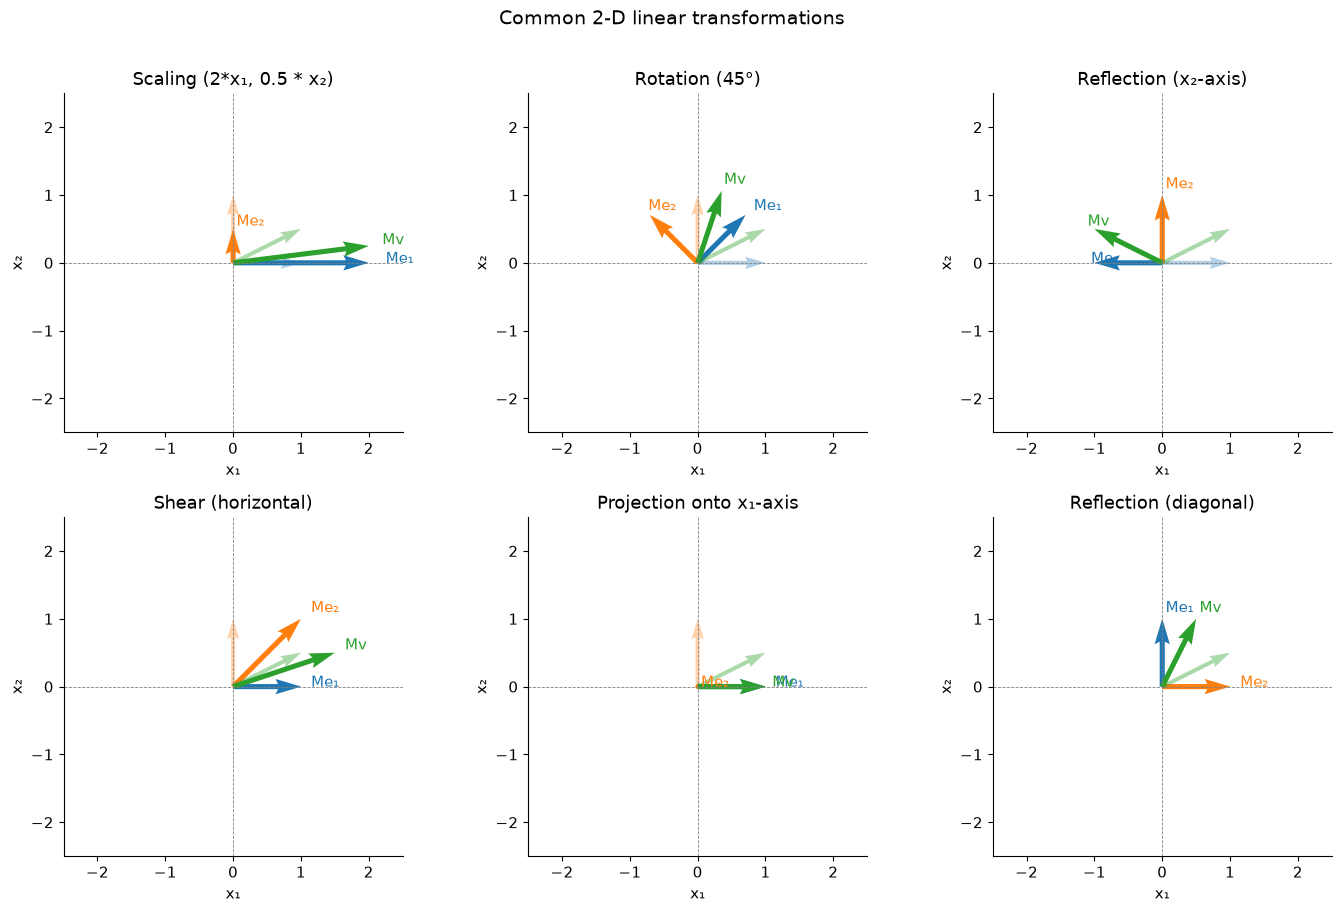

In [25]:
# --- 2D transformation gallery (as shown in the lecture)
v_test = np.array([1.0, 0.5])   # a test vector

transformations = {
    "Scaling (2*x₁, 0.5 * x₂)": np.array([[2.0, 0.0],
                                             [0.0, 0.5]]),
    "Rotation (45°)": np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)],
                                 [np.sin(np.pi/4),  np.cos(np.pi/4)]]),
    "Reflection (x₂-axis)": np.array([[-1.0, 0.0],
                                        [ 0.0, 1.0]]),
    "Shear (horizontal)": np.array([[1.0, 1.0],
                                     [0.0, 1.0]]),
    "Projection onto x₁-axis": np.array([[1.0, 0.0],
                                           [0.0, 0.0]]),
    "Reflection (diagonal)": np.array([[0.0, 1.0],
                                        [1.0, 0.0]]),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (title, M) in zip(axes.flatten(), transformations.items()):
    plot_transformation(M, v=v_test, title=title, ax=ax)

plt.suptitle("Common 2-D linear transformations", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


> **▶ Task 6.1 — 😎 ⭐️⭐️⭐️ Non-commutativity visualized.**
>
> Take the **Rotation (45°)** matrix `R` and the **Scaling** matrix `S` defined above. Apply them to the test vector `v_test` in both orders and plot the results side by side:
>
> - Left panel: apply scaling first, then rotation: $\mathbf{w}_1 = R(S\mathbf{v})$
> - Right panel: apply rotation first, then scaling: $\mathbf{w}_2 = S(R\mathbf{v})$
>
> Show the original vector $\mathbf{v}$ (green), the intermediate vector (orange), and the final vector (blue) in each panel. Do the two final vectors differ? What does this illustrate about the order of matrix operations?


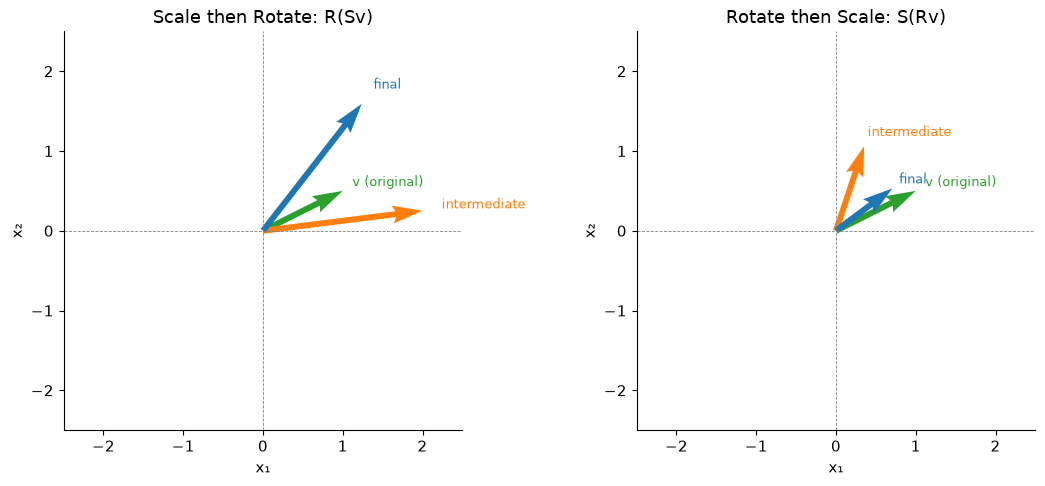

R(Sv) = [1.237 1.591]
S(Rv) = [0.707 0.53 ]


In [26]:
# TODO 6.1 — visualize non-commutativity of rotation and scaling
R = transformations["Rotation (45°)"]
S = transformations["Scaling (2*x₁, 0.5 * x₂)"]
v = v_test.copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, order, label in [
    (axes[0], [S, R], "Scale then Rotate: R(Sv)"),
    (axes[1], [R, S], "Rotate then Scale: S(Rv)"),
]:
    intermediate = order[0] @ v   # TO BE REMOVED
    final = order[1] @ intermediate   # TO BE REMOVED

    for vec, col, lbl in [
        (v,            "#2ca02c", "v (original)"),
        (intermediate, "#ff7f0e", "intermediate"),
        (final,        "#1f77b4", "final"),
    ]:
        ax.quiver(0, 0, vec[0], vec[1], angles="xy", scale_units="xy", scale=1,
                  color=col, width=0.015)
        ax.text(vec[0]*1.12, vec[1]*1.12, lbl, color=col, fontsize=9)

    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.axhline(0, color="gray", lw=0.6, ls="--")
    ax.axvline(0, color="gray", lw=0.6, ls="--")
    ax.set_aspect("equal")
    ax.set_title(label); ax.set_xlabel("x₁"); ax.set_ylabel("x₂")

plt.tight_layout()
plt.show()

print("R(Sv) =", (R @ (S @ v)).round(3))   # TO BE REMOVED
print("S(Rv) =", (S @ (R @ v)).round(3))   # TO BE REMOVED


<a id="section-8"></a>
## 8. Lego-style exercises

These exercises increase in difficulty. Complete as many as you can — the starred ones are optional challenges.


### Exercise 8.1 — 👨🏻‍🏫 ⭐️ Properties of the identity matrix

Verify **numerically** the following properties for a random $3 \times 3$ matrix `B`:

1. $B \cdot I = B$
2. $I \cdot B = B$
3. $I \cdot I = I$ (the identity is idempotent)
4. $I^{-1} = I$

Use `np.allclose` for all comparisons.


In [27]:
# TODO 8.1 — verify properties of the identity matrix
rng = np.random.default_rng(7)
B = rng.standard_normal((3, 3))
I3 = np.eye(3)

print("B @ I == B :", np.allclose(B @ I3, B))            # TO BE REMOVED
print("I @ B == B :", np.allclose(I3 @ B, B))            # TO BE REMOVED
print("I @ I == I :", np.allclose(I3 @ I3, I3))          # TO BE REMOVED
print("inv(I) == I:", np.allclose(np.linalg.inv(I3), I3)) # TO BE REMOVED


B @ I == B : True
I @ B == B : True
I @ I == I : True
inv(I) == I: True


### Exercise 8.2 — 🧐 ⭐️⭐️ Transpose of a product

An important algebraic identity: $(AB)^\top = B^\top A^\top$ (note the reversed order!).

Verify this numerically for two random matrices $A \in \mathbb{R}^{3 \times 4}$ and $B \in \mathbb{R}^{4 \times 2}$.

Then explain in words: *why* must the order reverse?


In [28]:
# TODO 8.2 — verify (AB)^T = B^T A^T
rng = np.random.default_rng(99)
A82 = rng.standard_normal((3, 4))
B82 = rng.standard_normal((4, 2))

lhs = (A82 @ B82).T             # (AB)^T — TO BE REMOVED
rhs = B82.T @ A82.T             # B^T A^T — TO BE REMOVED

print("(AB)^T shape :", lhs.shape)   # (2, 3)
print("B^T A^T shape:", rhs.shape)   # (2, 3)
print("Are they equal:", np.allclose(lhs, rhs))   # True — TO BE REMOVED


(AB)^T shape : (2, 3)
B^T A^T shape: (2, 3)
Are they equal: True


### Exercise 8.3 — 😎 ⭐️⭐️⭐️ Composition of rotations

The 2-D rotation matrix by angle $\theta$ is:

$$
R(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}
$$

1. Write a function `rotation_matrix(theta_deg)` that returns the rotation matrix for a given angle in degrees.
2. Verify that $R(\theta_1) R(\theta_2) = R(\theta_1 + \theta_2)$ for $\theta_1 = 30°$, $\theta_2 = 45°$.
3. Verify that $R(\theta)^{-1} = R(-\theta) = R(\theta)^\top$ (rotation matrices are *orthogonal*).
4. Plot the trajectory of the unit vector $\mathbf{e}_1 = [1, 0]$ as it is rotated from 0° to 360° in steps of 15°. The trajectory should trace out a unit circle.


R(30)@R(45) == R(75): True
R(45)^-1 == R(-45): True
R(45)^-1 == R(45).T: True


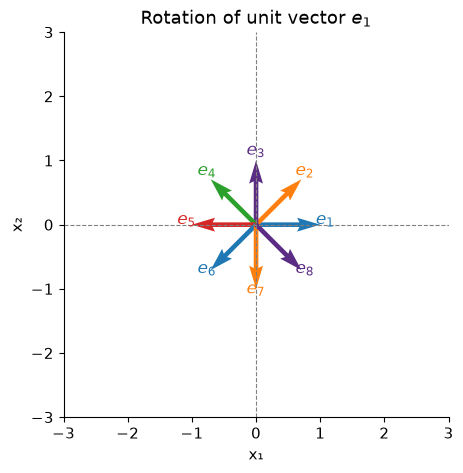

In [29]:
# TODO 8.3 — composition of rotations
def rotation_matrix(theta_deg):
    """Return the 2x2 rotation matrix for angle theta_deg (in degrees)."""
    theta = np.radians(theta_deg)   
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])

# 2. Verify composition
R30 = rotation_matrix(30)
R45 = rotation_matrix(45)
R75 = rotation_matrix(75)
print("R(30)@R(45) == R(75):", np.allclose(R30 @ R45, R75))   # TO BE REMOVED

# 3. Verify orthogonality
print("R(45)^-1 == R(-45):", np.allclose(np.linalg.inv(R45), rotation_matrix(-45)))   # TO BE REMOVED
print("R(45)^-1 == R(45).T:", np.allclose(np.linalg.inv(R45), R45.T))   # TO BE REMOVED

# 4. Plot unit-circle trajectory
e1 = np.array([1.0, 0.0])
angles = np.arange(0, 361 - 45, 45)
rotated = np.array([rotation_matrix(a) @ e1 for a in angles])   # TO BE REMOVED
ax = plot_vectors(rotated, labels=[fr"$e_{i}$" for i in range(1, len(angles)+1)], ax_label=False)
ax.set_title(rf'Rotation of unit vector $e_1$')
plt.show()



In [30]:
def plot_points_connected(points, ax=None, lim=None, ax_label=False, **plot_kwargs):
    """
    Plot a list of 2-D points, connect them in order, and optionally label points.

    Parameters
    ----------
    points : list of array-like, each of shape (2,) or (2,1)
        Example: [[x0,y0], [x1,y1], ...]
    ax : matplotlib Axes (created if None)
    lim : half-width of the axis range. If None, auto-scales with padding.
    ax_label : bool
        If True, enables x1/x2 axis labels like the previous vector plot.
    plot_kwargs : dict
        Optional styling passed to the line/markers, e.g.
        line_color, line_width, marker_color, marker_size, close_path, labels, colors, labels_format.

        Supported keys (with defaults):
          - line_color: "black"
          - line_width: 2.0
          - marker_color: "#1f77b4"
          - marker_size: 50
          - marker_edgecolor: "none"
          - close_path: False  (if True, connects last point back to first)
          - labels: None       (list of strings for each point)
          - colors: None       (list of colors for per-point markers)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    # Defaults / options
    line_color = plot_kwargs.get("line_color", "black")
    line_width = plot_kwargs.get("line_width", 2.0)
    marker_color = plot_kwargs.get("marker_color", "#1f77b4")
    marker_size = plot_kwargs.get("marker_size", 5)
    marker_edgecolor = plot_kwargs.get("marker_edgecolor", "none")
    close_path = plot_kwargs.get("close_path", True)

    labels = plot_kwargs.get("labels", None)
    colors = plot_kwargs.get("colors", None)
    if labels is not None and len(labels) != len(points):
        raise ValueError("labels must be the same length as points.")

    pts = np.array([np.array(p).flatten() for p in points], dtype=float)
    if pts.shape[1] != 2:
        raise ValueError("Each point must be shape (2,) or (2,1).")

    xs, ys = pts[:, 0], pts[:, 1]

    # Connect in order to form the letter/path
    if close_path:
        xs_plot = np.r_[xs, xs[0]]
        ys_plot = np.r_[ys, ys[0]]
    else:
        xs_plot, ys_plot = xs, ys

    ax.plot(xs_plot, ys_plot, color=line_color, lw=line_width)

    # Mark points (optionally per-point colors + labels)
    default_colors = ["#1f77b4", "#ff7f0e", "#5b2c83", "#2ca02c", "#d62728"]
    if colors is None:
        colors = [marker_color] * len(points)

    for i, (x, y) in enumerate(pts):
        ax.scatter([x], [y], s=marker_size, c=[colors[i % len(colors)]],
                   edgecolors=marker_edgecolor, zorder=3)

        if labels is not None:
            ax.text(x * 1.02 if x != 0 else 0.02, y * 1.02 if y != 0 else 0.02,
                    str(labels[i]), color=colors[i % len(colors)],
                    fontsize=12, ha="center", va="center")

    # Limits
    if lim is None:
        max_abs = np.max(np.abs(pts))
        lim = 1.1 * max_abs if max_abs > 0 else 1.0

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.axvline(0, color="gray", lw=0.8, ls="--")
    ax.set_aspect("equal")

    if ax_label:
        ax.set_xlabel("x₁")
        ax.set_ylabel("x₂")

    return ax

def scale_letter_interact(a=1, b=0, c=0, d=1):
    fig, ax = plt.subplots(figsize=(5, 5))
    pts = [
        [3, 4], [3, 5], [0, 5], [0, 0], [1, 0], [1, 1.8],
        [2.5, 1.8], [2.5, 2.8], [1, 2.8], [1, 4]
    ]

    # Apply linear transform to each point
    new_pts = []
    for pt in pts:
        x = a * pt[0] + b * pt[1]
        y = c * pt[0] + d * pt[1]
        new_pts.append([x, y])
    
    plot_points_connected(pts, ax=ax, close_path=True, lim = 8)
    plot_points_connected(new_pts, ax=ax, close_path=True, lim = 8)
_ = interact(scale_letter_interact, a = (-1, 1, 0.1), b = (-1, 1, 0.1),
             c = (-1, 1, 0.1), d = (-1, 1, 0.1))


interactive(children=(FloatSlider(value=1.0, description='a', max=1.0, min=-1.0), FloatSlider(value=0.0, descr…

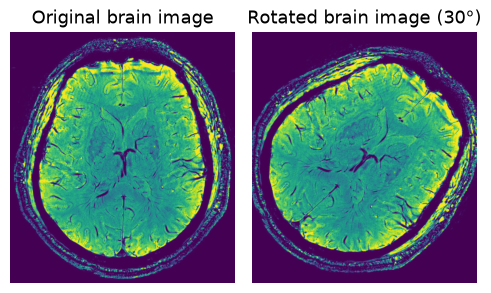

In [31]:
def rotate_image_2x2(img, theta_deg, background=0):
    """
    img: 2D array (H, W)
    background: value for pixels that map outside the input
    """
    H, W = img.shape
    R = rotation_matrix(theta_deg)
    Rinv = np.linalg.inv(R)

    # grid of output pixel coordinates (x=col, y=row)
    y_out, x_out = np.indices((H, W))  # each is (H, W)

    # rotate around center
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
    x = x_out - cx
    y = y_out - cy

    # inverse-map: where do these output pixels come from in the input?
    # [x_in, y_in]^T = Rinv @ [x_out-cx, y_out-cy]^T
    x_in = Rinv[0, 0] * x + Rinv[0, 1] * y + cx
    y_in = Rinv[1, 0] * x + Rinv[1, 1] * y + cy

    # nearest-neighbor sampling (simple + fast). If you want bilinear, say so.
    x0 = np.rint(x_in).astype(int)
    y0 = np.rint(y_in).astype(int)

    out = np.full((H, W), background, dtype=img.dtype)

    valid = (x0 >= 0) & (x0 < W) & (y0 >= 0) & (y0 < H)
    out[valid] = img[y0[valid], x0[valid]]
    return out

brain_image = plt.imread("assets/09/brain_image.jpg")
brain_imag_single_channel = brain_image[:, :, 0]


fig, ax = plt.subplots(1, 2, figsize=(5, 5))
ax[0].imshow(brain_imag_single_channel)
ax[0].set_title("Original brain image")
ax[0].axis('off')
brain_rotated = rotate_image_2x2(brain_imag_single_channel, 45, background=0)
ax[1].imshow(brain_rotated)
ax[1].set_title("Rotated brain image (30°)")
ax[1].axis('off')
plt.tight_layout()
plt.show()

## About this notebook

**Course:** Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)  
**Instructor:** Prof. Sami El-Boustani  
**Corresponding TAs** Nosrat Mohammadi, Jonathan Wirsich & Caroline Lourencoalves  
**Week 9:** Linear Algebra Fundamentals

Further read:
[Matrix transformation](https://courses.cs.umbc.edu/graduate/691cv/lectures/11_image-transformations.pdf)

For feedback or questions, use the course GPT bot: https://chatgpt.com/g/g-69fc9bfc9a748191a912a124800d9254-qmn-teaching-assistant-bot
